# **00. DOWNLOAD DATASET & EXPLORATORY DATA ANALYSIS (EDA)**

Notebook này thực hiện phân tích khám phá dữ liệu ban đầu cho bộ **Amazon Sales Report** từ Kaggle. Mục tiêu không chỉ là xem dữ liệu có gì, mà còn xác định rõ các vấn đề cần xử lý khi xây dựng kiến trúc **Lakehouse Bronze - Silver - Gold** cho bài toán phân tích doanh thu thương mại điện tử.

Các câu hỏi chính:
1. Dữ liệu gốc gồm bao nhiêu dòng, bao nhiêu cột và schema hiện tại ra sao?
2. Những cột nào bị thiếu dữ liệu, sai kiểu dữ liệu hoặc có nguy cơ gây lỗi khi xử lý bằng Spark/Delta?
3. Khoá nghiệp vụ nào có thể dùng để khử trùng lặp đơn hàng?
4. Những chiều phân tích nào nên được đưa vào tầng Gold để phục vụ dashboard và truy vấn phân tích?


## **1. Import thư viện & Thiết lập**
Chúng ta sử dụng các thư viện phổ biến cho EDA gồm Pandas, Numpy, Matplotlib và Seaborn. Phần cấu hình hiển thị giúp biểu đồ nhất quán với notebook trực quan hóa của dự án.


In [1]:

# Nếu môi trường chưa có các thư viện cần thiết, hãy mở comment dòng dưới và chạy một lần.
# !pip install opendatasets pandas numpy matplotlib seaborn

from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["font.family"] = "DejaVu Sans"
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## **2. Tải dữ liệu từ Kaggle**
Bộ dữ liệu được lấy từ Kaggle bằng thư viện `opendatasets`. Nếu thư mục dữ liệu đã tồn tại trong project, notebook sẽ bỏ qua bước tải lại để tránh ghi đè hoặc tốn thời gian.

> Khi tải lần đầu, Kaggle có thể yêu cầu `username` và `key` trong file `kaggle.json`.


In [2]:

DATASET_URL = "https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data"
DATASET_DIR_NAME = "unlock-profits-with-e-commerce-sales-data"

current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir
notebook_dir = project_root / "notebooks"
data_dir = notebook_dir / DATASET_DIR_NAME
csv_path = data_dir / "Amazon Sale Report.csv"

print(f"Project root: {project_root}")
print(f"Dataset path: {csv_path}")

if not csv_path.exists():
    import opendatasets as od
    notebook_dir.mkdir(parents=True, exist_ok=True)
    os.chdir(notebook_dir)
    od.download(DATASET_URL)
    os.chdir(current_dir)
else:
    print("Dataset đã tồn tại, bỏ qua bước download.")


Project root: /home/linhtd3993/workspace/projects/HW_7
Dataset path: /home/linhtd3993/workspace/projects/HW_7/notebooks/unlock-profits-with-e-commerce-sales-data/Amazon Sale Report.csv
Dataset đã tồn tại, bỏ qua bước download.


## **3. Đọc dữ liệu thô & Tổng quan ban đầu**
Ở bước này chúng ta đọc file CSV chính `Amazon Sale Report.csv`. Tham số `low_memory=False` giúp Pandas đọc dữ liệu ổn định hơn khi một số cột có kiểu dữ liệu không đồng nhất.


In [3]:

df = pd.read_csv(csv_path, low_memory=False)

print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng, {df.shape[1]} cột")
df.head()


Kích thước dữ liệu: 128,975 dòng, 24 cột


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,"400,081.00",IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,"560,085.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,"410,210.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,"605,008.00",IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,"600,073.00",IN,NaN,False,NaN,NaN


### **Thông tin Schema & Kiểu dữ liệu**
Phần này giúp xác định những cột cần chuẩn hóa tên, ép kiểu hoặc loại bỏ trước khi ghi vào tầng Silver.


In [4]:

df.info()

schema_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(dtype) for dtype in df.dtypes],
    "non_null_count": df.notna().sum().values,
    "null_count": df.isna().sum().values,
    "unique_count": df.nunique(dropna=True).values,
})
schema_summary


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

,column,dtype,non_null_count,null_count,unique_count
0,index,int64,128975,0,128975
1,Order ID,object,128975,0,120378
2,Date,object,128975,0,91
3,Status,object,128975,0,13
4,Fulfilment,object,128975,0,2
5,Sales Channel,object,128975,0,2
6,ship-service-level,object,128975,0,2
7,Style,object,128975,0,1377
8,SKU,object,128975,0,7195
9,Category,object,128975,0,9


### **Nhận xét chuyên sâu (Insights):**
* Dữ liệu có dạng **order item level**, mỗi dòng đại diện cho một sản phẩm/SKU trong một đơn hàng thay vì chỉ một đơn hàng tổng hợp.
* Một số cột cần được chuẩn hóa tên trước khi đưa vào Spark/Delta, đặc biệt là các cột có dấu cách hoặc dấu gạch ngang như `Sales Channel `, `ship-service-level`, `ship-postal-code`.
* `Date` đang là chuỗi, `ship-postal-code` bị Pandas đọc thành số thực, còn `Amount` có giá trị thiếu. Đây là ba điểm cần xử lý rõ ở tầng Silver.


## **4. Phân tích chất lượng dữ liệu (Data Quality Audit)**
Chúng ta tập trung vào các lỗi ảnh hưởng trực tiếp đến pipeline: missing values, duplicate records, kiểu dữ liệu ngày tháng và các cột ít giá trị phân tích.


In [5]:

missing_values = df.isna().sum()
missing_percentage = missing_values / len(df) * 100
missing_df = (
    pd.DataFrame({"Missing Count": missing_values, "Percentage (%)": missing_percentage})
    .query("`Missing Count` > 0")
    .sort_values("Missing Count", ascending=False)
)
missing_df


,Missing Count,Percentage (%)
fulfilled-by,89698,69.55
promotion-ids,49153,38.11
Unnamed: 22,49050,38.03
currency,7795,6.04
Amount,7795,6.04
Courier Status,6872,5.33
ship-city,33,0.03
ship-state,33,0.03
ship-postal-code,33,0.03
ship-country,33,0.03


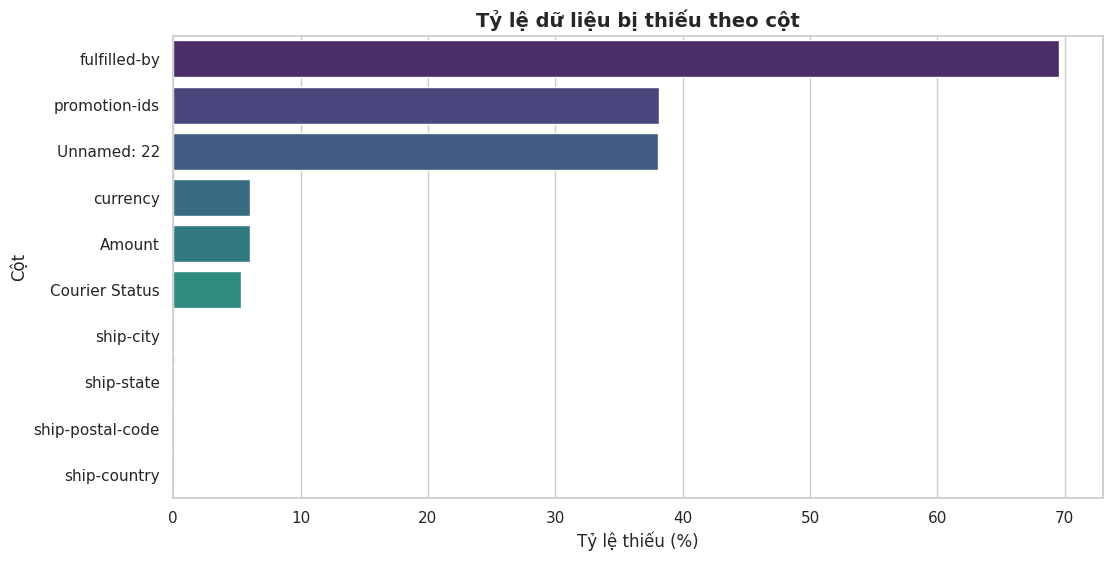

In [6]:

plt.figure(figsize=(12, 6))
plot_df = missing_df.reset_index().rename(columns={"index": "Column"})
sns.barplot(data=plot_df, x="Percentage (%)", y="Column", hue="Column", palette="viridis", legend=False)
plt.title("Tỷ lệ dữ liệu bị thiếu theo cột", fontsize=14, fontweight="bold")
plt.xlabel("Tỷ lệ thiếu (%)")
plt.ylabel("Cột")
plt.show()


### **Nhận xét chuyên sâu (Insights):**
* `fulfilled-by` thiếu khoảng **70%**, chủ yếu vì các đơn do Amazon fulfilment không cần giá trị ở cột này. Đây không nên là lỗi nghiêm trọng mà cần được hiểu theo ngữ cảnh vận hành.
* `promotion-ids` thiếu khoảng **38%**, phản ánh nhiều đơn hàng không dùng khuyến mãi. Có thể chuyển thành biến nhị phân `has_promotion` thay vì giữ nguyên chuỗi dài.
* `Amount` và `currency` thiếu khoảng **6%**. Phần lớn các dòng này liên quan đến đơn bị hủy, nên tầng Silver cần xử lý theo quy tắc nghiệp vụ thay vì điền trung bình một cách máy móc.
* Các cột địa chỉ giao hàng chỉ thiếu rất ít, có thể lọc bỏ hoặc gắn nhãn `UNKNOWN` tùy mục tiêu phân tích.


### **Kiểm tra dữ liệu trùng lặp**
Vì dữ liệu ở cấp dòng sản phẩm trong đơn hàng, khoá tự nhiên hợp lý nhất là tổ hợp `Order ID` và `SKU`. Ta kiểm tra cả trùng lặp toàn dòng và trùng lặp theo khóa nghiệp vụ.


In [7]:

duplicate_checks = pd.DataFrame({
    "Check": [
        "Full row duplicate",
        "Duplicate by Order ID + SKU",
        "Duplicate by Order ID + ASIN",
        "Duplicate by Order ID + SKU + Date",
    ],
    "Duplicate Count": [
        df.duplicated().sum(),
        df.duplicated(subset=["Order ID", "SKU"]).sum(),
        df.duplicated(subset=["Order ID", "ASIN"]).sum(),
        df.duplicated(subset=["Order ID", "SKU", "Date"]).sum(),
    ]
})
duplicate_checks


,Check,Duplicate Count
0,Full row duplicate,0
1,Duplicate by Order ID + SKU,7
2,Duplicate by Order ID + ASIN,7
3,Duplicate by Order ID + SKU + Date,7


In [8]:

duplicated_key_rows = df[df.duplicated(subset=["Order ID", "SKU"], keep=False)].sort_values(["Order ID", "SKU"])
duplicated_key_rows.head(20)


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
85790,85790,171-3249942-2207542,05-03-22,Shipped,Amazon,Amazon.in,Expedited,SET323,SET323-KR-NP-XL,Set,XL,B09NDKKM7P,Shipped,1,INR,939.00,PUNE,MAHARASHTRA,"411,057.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
85791,85791,171-3249942-2207542,05-03-22,Shipped,Amazon,Amazon.in,Expedited,SET323,SET323-KR-NP-XL,Set,XL,B09NDKKM7P,Shipped,1,INR,939.00,PUNE,MAHARASHTRA,"411,057.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
79844,79844,171-9628368-5329958,05-07-22,Cancelled,Amazon,Amazon.in,Expedited,J0329,J0329-KR-L,kurta,L,B09KXRB7JV,Cancelled,0,NaN,NaN,ERNAKULAM,KERALA,"682,017.00",IN,NaN,False,NaN,False
79845,79845,171-9628368-5329958,05-07-22,Cancelled,Amazon,Amazon.in,Expedited,J0329,J0329-KR-L,kurta,L,B09KXRB7JV,Cancelled,0,NaN,NaN,ERNAKULAM,KERALA,"682,017.00",IN,NaN,False,NaN,False
86418,86418,405-8669298-3850736,05-03-22,Shipped,Amazon,Amazon.in,Expedited,MEN5025,MEN5025-KR-XXXL,kurta,3XL,B08YYQS8FH,Shipped,1,INR,533.00,GHAZIABAD,UTTAR PRADESH,"201,010.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
86419,86419,405-8669298-3850736,05-03-22,Shipped,Amazon,Amazon.in,Expedited,MEN5025,MEN5025-KR-XXXL,kurta,3XL,B08YYQS8FH,Shipped,1,INR,533.00,GHAZIABAD,UTTAR PRADESH,"201,010.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
30660,30660,406-0372545-6086735,04-12-22,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,B08B3YPD63,Cancelled,0,NaN,NaN,Siliguri,WEST BENGAL,"734,008.00",IN,NaN,False,NaN,NaN
30661,30661,406-0372545-6086735,04-12-22,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,B08B3YPD63,Cancelled,0,NaN,NaN,Siliguri,WEST BENGAL,"734,008.00",IN,NaN,False,NaN,NaN
98954,98954,407-4853873-4978725,06-22-22,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-M,Set,M,B08XNJG8B1,Shipped,1,INR,"1,163.00",Zirakpur,Punjab,"140,603.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
98955,98955,407-4853873-4978725,06-22-22,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-M,Set,M,B08XNJG8B1,Shipped,1,INR,"1,163.00",Zirakpur,Punjab,"140,603.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


### **Nhận xét chuyên sâu (Insights):**
* Không có dòng trùng lặp hoàn toàn, nhưng vẫn có một số dòng trùng theo cặp `Order ID` + `SKU`.
* Với pipeline Silver, nên dùng `dropDuplicates(["order_id", "sku"])` sau khi chuẩn hóa tên cột. Nếu muốn bảo toàn lịch sử thay đổi trạng thái đơn hàng, cần bổ sung trường thời gian ingest ở Bronze và dùng logic chọn bản ghi mới nhất.


### **Kiểm tra cột ngày tháng và kiểu dữ liệu nhạy cảm**
Các cột như `Date`, `Amount`, `Qty`, `ship-postal-code` thường gây lỗi khi chuyển từ CSV sang Spark DataFrame nếu không khai báo schema rõ ràng.


In [9]:

parsed_date = pd.to_datetime(df["Date"], format="%m-%d-%y", errors="coerce")

print("Một số giá trị Date mẫu:")
print(df["Date"].dropna().unique()[:10])
print("\nKhoảng thời gian dữ liệu:")
print(f"Từ {parsed_date.min().date()} đến {parsed_date.max().date()}")
print(f"Số dòng parse Date lỗi: {parsed_date.isna().sum():,}")

print("\nKiểu dữ liệu thực tế của ship-postal-code:")
print(df["ship-postal-code"].apply(type).value_counts())

print("\nThống kê Qty và Amount:")
df[["Qty", "Amount"]].describe()


Một số giá trị Date mẫu:
['04-30-22' '04-29-22' '04-28-22' '04-27-22' '04-26-22' '04-25-22'
 '04-24-22' '04-23-22' '04-22-22' '04-21-22']

Khoảng thời gian dữ liệu:
Từ 2022-03-31 đến 2022-06-29
Số dòng parse Date lỗi: 0

Kiểu dữ liệu thực tế của ship-postal-code:
ship-postal-code
<class 'float'>    128975
Name: count, dtype: int64

Thống kê Qty và Amount:


,Qty,Amount
count,"128,975.00","121,180.00"
mean,0.90,648.56
std,0.31,281.21
min,0.00,0.00
25%,1.00,449.00
50%,1.00,605.00
75%,1.00,788.00
max,15.00,"5,584.00"


In [10]:

amount_null_by_status = (
    df[df["Amount"].isna()]["Status"]
    .value_counts(dropna=False)
    .rename_axis("Status")
    .reset_index(name="Rows with Missing Amount")
)
amount_null_by_status


,Status,Rows with Missing Amount
0,Cancelled,7566
1,Shipped,208
2,Shipped - Delivered to Buyer,8
3,Shipping,8
4,Shipped - Returned to Seller,3
5,Pending,2


### **Nhận xét chuyên sâu (Insights):**
* `Date` có định dạng nhất quán kiểu `MM-DD-YY` và parse được toàn bộ, phù hợp để chuẩn hóa thành `date` ở tầng Silver.
* `ship-postal-code` nên được ép sang **string**, không nên giữ kiểu số thực vì mã bưu điện là định danh địa lý, không phải đại lượng để tính toán.
* `Qty` có giá trị 0 ở nhiều đơn bị hủy. Vì vậy doanh thu phân tích nên ưu tiên các trạng thái đã giao/đã ship hoặc cần tách riêng nhóm cancelled.
* `Amount` bị thiếu chủ yếu ở trạng thái `Cancelled`, do đó có thể điền `0.0` cho phân tích doanh thu sau khi đã tạo cột trạng thái chuẩn hóa.


## **5. Phân tích đơn biến (Univariate Analysis)**
Phần này khảo sát phân phối của các biến phân loại và biến số chính: trạng thái đơn hàng, category, size, số lượng và giá trị đơn hàng.


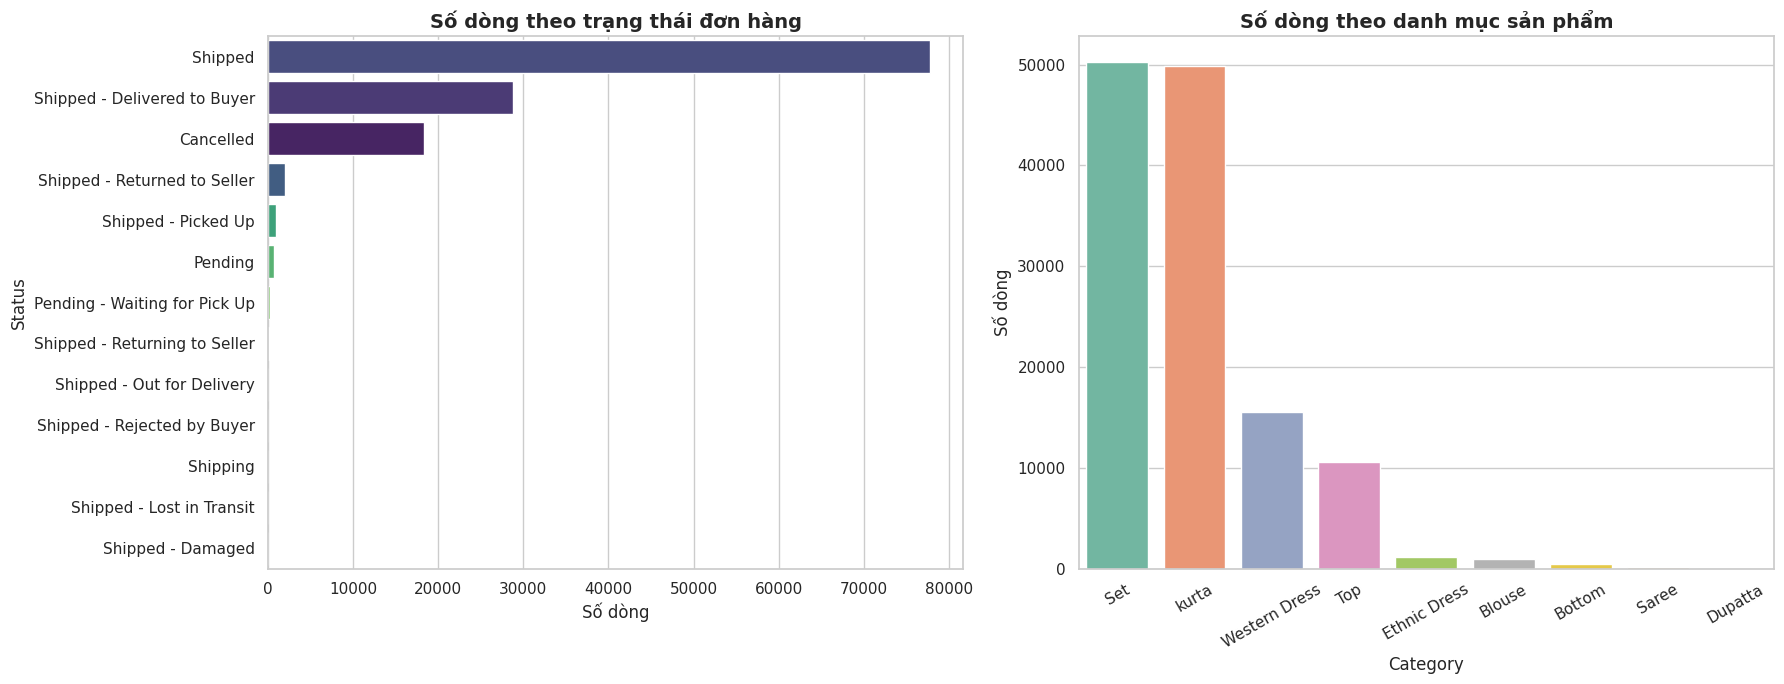

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

status_order = df["Status"].value_counts().index
sns.countplot(data=df, y="Status", order=status_order, hue="Status", palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Số dòng theo trạng thái đơn hàng", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Số dòng")
axes[0].set_ylabel("Status")

category_order = df["Category"].value_counts().index
sns.countplot(data=df, x="Category", order=category_order, hue="Category", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Số dòng theo danh mục sản phẩm", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Số dòng")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


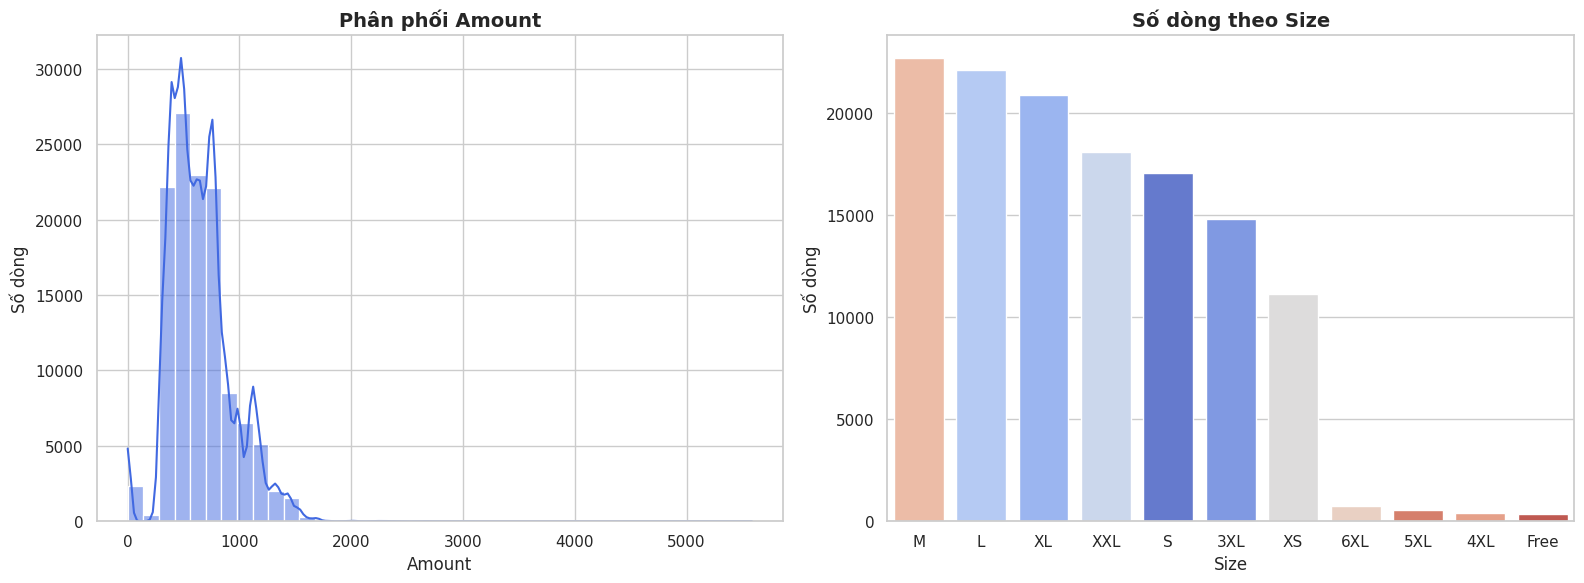

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df["Amount"].dropna(), bins=40, kde=True, color="royalblue", ax=axes[0])
axes[0].set_title("Phân phối Amount", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Số dòng")

size_order = df["Size"].value_counts().index
sns.countplot(data=df, x="Size", order=size_order, hue="Size", palette="coolwarm", legend=False, ax=axes[1])
axes[1].set_title("Số dòng theo Size", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Size")
axes[1].set_ylabel("Số dòng")

plt.tight_layout()
plt.show()


### **Nhận xét chuyên sâu (Insights):**
* Dữ liệu tập trung mạnh ở các trạng thái đã vận chuyển như `Shipped` và `Shipped - Delivered to Buyer`, nhưng nhóm `Cancelled` cũng đủ lớn để cần phân tích riêng.
* Ba nhóm sản phẩm chủ lực là **Set**, **kurta** và **Western Dress**. Đây là các chiều phù hợp để partition hoặc aggregate trong tầng Gold.
* `Amount` lệch phải nhẹ: phần lớn đơn hàng có giá trị trung bình/thấp, một số ít đơn có giá trị cao hơn đáng kể. Khi xây dựng dashboard, nên dùng cả median và average để tránh hiểu sai do outlier.
* Size phổ biến nhất xoay quanh `M`, `L`, `XL`, `XXL`, phản ánh tập sản phẩm thời trang có nhu cầu lớn ở các size phổ thông.


## **6. Phân tích đa biến (Multivariate Analysis)**
Chúng ta khảo sát quan hệ giữa doanh thu, trạng thái đơn hàng, category, fulfilment và địa lý giao hàng để xác định các bảng tổng hợp nên có ở tầng Gold.


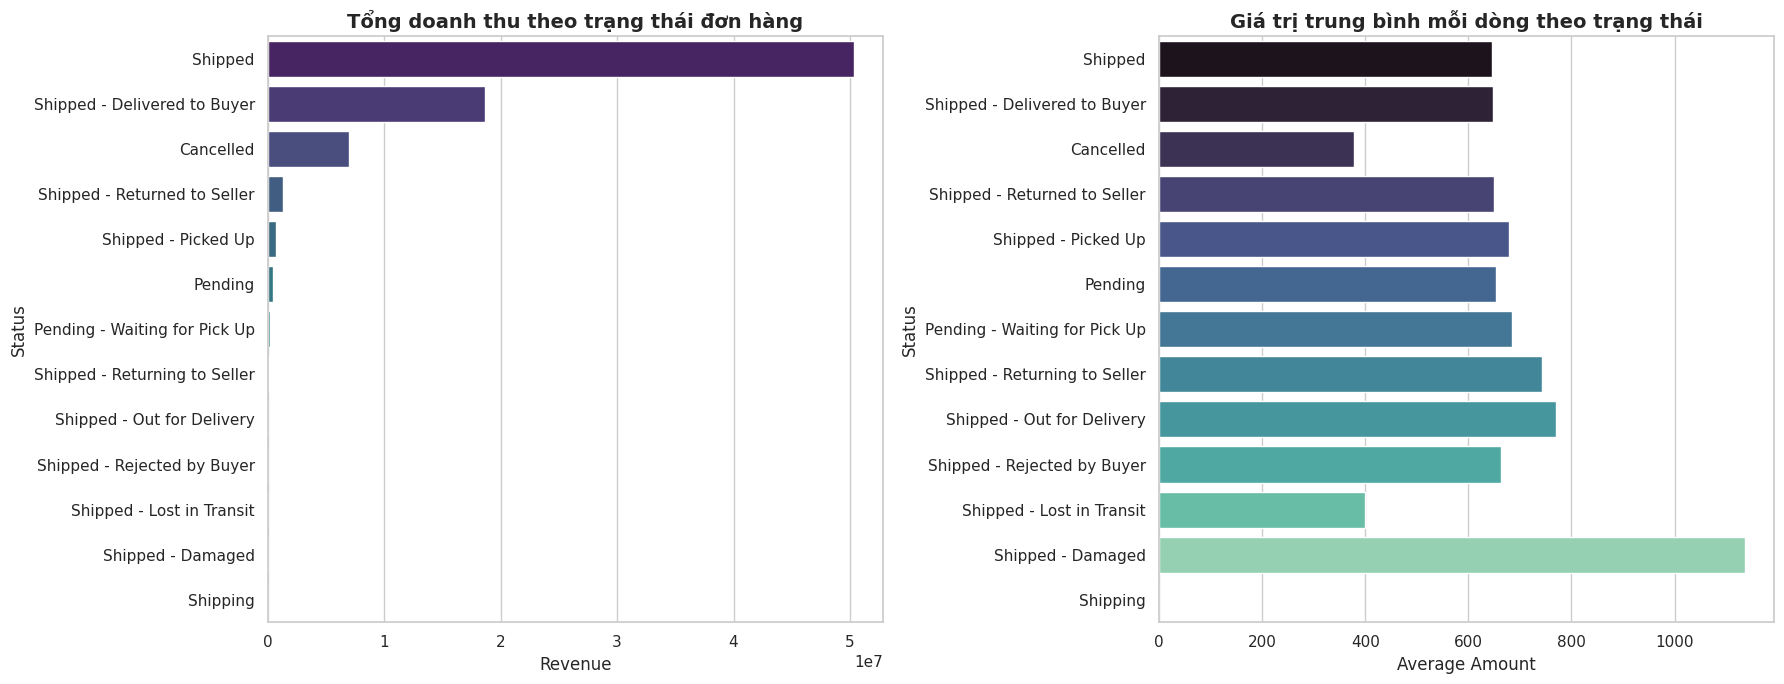

,Status,order_lines,revenue,avg_amount
3,Shipped,77804,"50,324,255.00",646.81
5,Shipped - Delivered to Buyer,28769,"18,650,815.00",648.30
0,Cancelled,18332,"6,919,284.30",377.44
10,Shipped - Returned to Seller,1953,"1,269,644.00",650.10
8,Shipped - Picked Up,973,"661,252.00",679.60
1,Pending,658,"430,271.00",653.91
2,Pending - Waiting for Pick Up,281,"192,138.00",683.77
11,Shipped - Returning to Seller,145,"107,620.00",742.21
7,Shipped - Out for Delivery,35,"26,971.00",770.60
9,Shipped - Rejected by Buyer,11,"7,295.00",663.18


In [13]:

status_revenue = (
    df.assign(Amount_Filled=df["Amount"].fillna(0))
    .groupby("Status", as_index=False)
    .agg(order_lines=("Order ID", "count"), revenue=("Amount_Filled", "sum"), avg_amount=("Amount_Filled", "mean"))
    .sort_values("revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=status_revenue, x="revenue", y="Status", hue="Status", palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Tổng doanh thu theo trạng thái đơn hàng", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Status")

sns.barplot(data=status_revenue, x="avg_amount", y="Status", hue="Status", palette="mako", legend=False, ax=axes[1])
axes[1].set_title("Giá trị trung bình mỗi dòng theo trạng thái", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Average Amount")
axes[1].set_ylabel("Status")

plt.tight_layout()
plt.show()

status_revenue


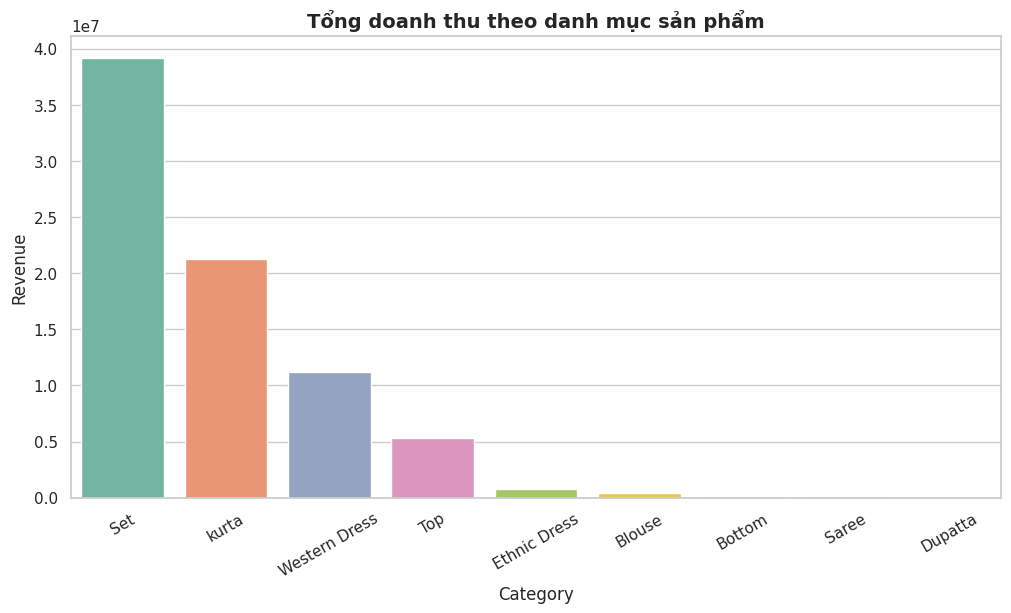

,Category,order_lines,qty,revenue,avg_amount
5,Set,50284,45289,"39,204,124.03",779.65
8,kurta,49877,45045,"21,299,546.70",427.04
7,Western Dress,15500,13943,"11,216,072.69",723.62
6,Top,10622,9903,"5,347,792.30",503.46
3,Ethnic Dress,1159,1053,"791,217.66",682.67
0,Blouse,926,863,"458,408.18",495.04
1,Bottom,440,398,"150,667.98",342.43
4,Saree,164,152,"123,933.76",755.69
2,Dupatta,3,3,915.00,305.00


In [14]:

category_revenue = (
    df.assign(Amount_Filled=df["Amount"].fillna(0))
    .groupby("Category", as_index=False)
    .agg(order_lines=("Order ID", "count"), qty=("Qty", "sum"), revenue=("Amount_Filled", "sum"), avg_amount=("Amount_Filled", "mean"))
    .sort_values("revenue", ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=category_revenue, x="Category", y="revenue", hue="Category", palette="Set2", legend=False)
plt.title("Tổng doanh thu theo danh mục sản phẩm", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.show()

category_revenue


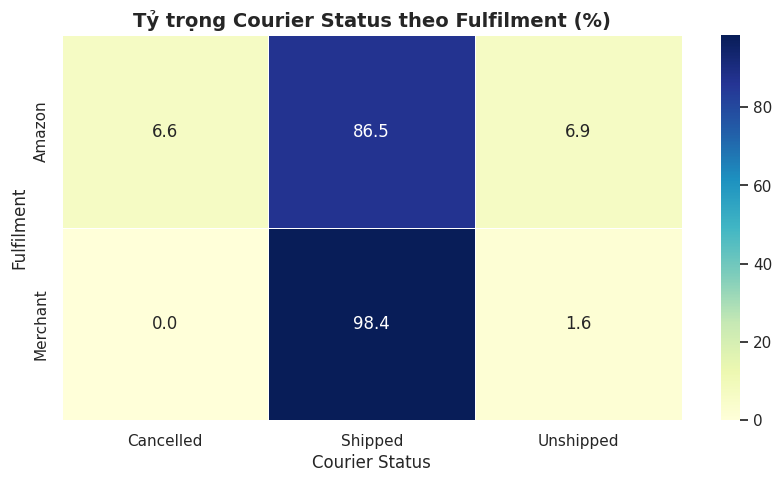

Courier Status,Cancelled,Shipped,Unshipped
Fulfilment,,,
Amazon,6.62,86.52,6.86
Merchant,0.00,98.38,1.62


In [15]:

fulfilment_status = pd.crosstab(df["Fulfilment"], df["Courier Status"], normalize="index") * 100

plt.figure(figsize=(10, 5))
sns.heatmap(fulfilment_status, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5)
plt.title("Tỷ trọng Courier Status theo Fulfilment (%)", fontsize=14, fontweight="bold")
plt.xlabel("Courier Status")
plt.ylabel("Fulfilment")
plt.show()

fulfilment_status


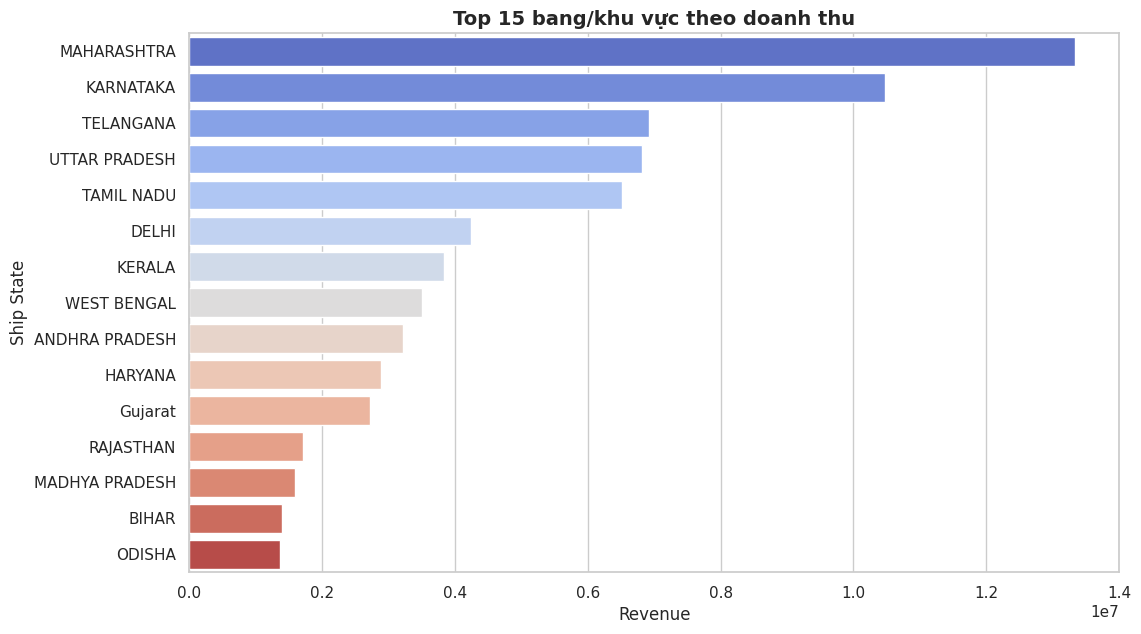

,ship-state,order_lines,revenue
28,MAHARASHTRA,22260,"13,335,534.14"
23,KARNATAKA,17326,"10,481,114.37"
57,TELANGANA,11330,"6,916,615.65"
59,UTTAR PRADESH,10638,"6,816,642.08"
56,TAMIL NADU,11483,"6,515,650.11"
14,DELHI,6782,"4,235,215.97"
24,KERALA,6585,"3,830,227.58"
61,WEST BENGAL,5963,"3,507,880.44"
1,ANDHRA PRADESH,5430,"3,219,831.72"
19,HARYANA,4415,"2,882,092.99"


In [16]:

state_revenue = (
    df.assign(Amount_Filled=df["Amount"].fillna(0))
    .groupby("ship-state", dropna=False, as_index=False)
    .agg(order_lines=("Order ID", "count"), revenue=("Amount_Filled", "sum"))
    .sort_values("revenue", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))
sns.barplot(data=state_revenue, x="revenue", y="ship-state", hue="ship-state", palette="coolwarm", legend=False)
plt.title("Top 15 bang/khu vực theo doanh thu", fontsize=14, fontweight="bold")
plt.xlabel("Revenue")
plt.ylabel("Ship State")
plt.show()

state_revenue


### **Nhận xét chuyên sâu (Insights):**
* Doanh thu chủ yếu đến từ các đơn đã ship hoặc đã giao cho người mua; do đó dashboard nên có filter trạng thái để tách doanh thu thực tế khỏi đơn bị hủy/chưa hoàn tất.
* `Set` và `kurta` vừa có số lượng dòng lớn vừa tạo doanh thu cao, nên đây là hai danh mục trọng tâm khi xây dựng bảng aggregate theo category.
* Fulfilment qua Amazon chiếm tỷ trọng lớn hơn Merchant, nhưng cần theo dõi `Courier Status` để đánh giá rủi ro đơn chưa ship hoặc hủy.
* Các bang như **Maharashtra**, **Karnataka**, **Tamil Nadu**, **Telangana** xuất hiện nổi bật trong phân phối đơn hàng/doanh thu, phù hợp để đưa vào dashboard địa lý.


## **7. Đề xuất xử lý cho Lakehouse Pipeline**
Từ các phát hiện EDA, ta xác định rõ trách nhiệm của từng tầng dữ liệu.


### **7.1 Bronze Layer - Lưu dữ liệu thô có kiểm soát**
* Đọc nguyên trạng các file CSV từ thư mục Kaggle và lưu vào Bronze.
* Thêm metadata ingest như `ingest_timestamp`, `source_file`, `source_system` để truy vết.
* Không sửa giá trị nghiệp vụ ở Bronze, chỉ đảm bảo dữ liệu được lưu lại đầy đủ và có thể tái xử lý.

### **7.2 Silver Layer - Làm sạch và chuẩn hóa schema**
* Chuẩn hóa tên cột sang `snake_case`: ví dụ `Order ID` -> `order_id`, `Sales Channel ` -> `sales_channel`, `ship-postal-code` -> `ship_postal_code`.
* Ép kiểu dữ liệu:
  * `date`: parse từ `MM-dd-yy` sang `DateType`.
  * `qty`: Integer.
  * `amount`: Double/Decimal, điền `0.0` khi thiếu nếu trạng thái là cancelled hoặc không phát sinh doanh thu.
  * `ship_postal_code`: String.
  * `b2b`: Boolean.
* Tạo cột dẫn xuất: `order_month`, `order_year`, `is_cancelled`, `has_promotion`, `normalized_status`.
* Khử trùng lặp theo `order_id + sku`, hoặc theo `order_id + sku + ingest_timestamp` nếu pipeline cần giữ bản mới nhất.
* Loại bỏ cột nhiễu/ít ý nghĩa như `unnamed_22` sau khi xác nhận không có nghiệp vụ sử dụng.

### **7.3 Gold Layer - Bảng phục vụ Analytics**
* `gold_sales_daily`: doanh thu, số đơn, số lượng bán theo ngày.
* `gold_sales_by_category`: doanh thu, số lượng, average amount theo category/size.
* `gold_sales_by_state`: doanh thu và số đơn theo bang/thành phố giao hàng.
* `gold_fulfilment_status`: tỷ lệ shipped/unshipped/cancelled theo fulfilment và courier status.
* `gold_b2b_summary`: so sánh doanh thu và số lượng giữa B2B và B2C.


## **8. Tổng kết EDA & Hướng triển khai tiếp theo**
1. Bộ dữ liệu đủ lớn để mô phỏng một pipeline Lakehouse cơ bản với hơn một trăm nghìn dòng order item.
2. Các vấn đề quan trọng nhất nằm ở **schema không chuẩn**, **missing amount/currency**, **postal code bị đọc sai kiểu**, và **một số khóa order item bị trùng**.
3. Dữ liệu có nhiều chiều phân tích hữu ích: thời gian, category, size, fulfilment, status, B2B và địa lý giao hàng.
4. Pipeline nên ưu tiên thiết kế Silver sạch, ổn định trước khi aggregate sang Gold; nếu Silver xử lý tốt status và amount thì dashboard doanh thu sẽ đáng tin cậy hơn nhiều.
5. Notebook này đóng vai trò tài liệu phân tích ban đầu để triển khai các file `01_ingest_to_bronze.py`, `02_clean_to_silver.py` và `03_aggregate_to_gold.py` trong thư mục `lakehouse_pipeline`.
